# MSA 2026 Phase 2 - Part 2: Maximum Temperature Prediction from Weather Data

## 1. Load and check the dataset

In [50]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

In [74]:
weather_df = pd.read_csv("Summary of Weather.csv")

weather_df.head(10)

/tmp/ipykernel_1475/2997305667.py:1: DtypeWarning: Columns (7,8,18,25) have mixed types. Specify dtype option on import or set low_memory=False.
  weather_df = pd.read_csv("Summary of Weather.csv")


,STA,Date,Precip,WindGustSpd,MaxTemp,MinTemp,MeanTemp,Snowfall,PoorWeather,YR,...,FB,FTI,ITH,PGT,TSHDSBRSGF,SD3,RHX,RHN,RVG,WTE
0,10001,1942/7/1,1.016,NaN,25.555556,22.222222,23.888889,0.0,NaN,42,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,10001,1942/7/2,0,NaN,28.888889,21.666667,25.555556,0.0,NaN,42,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,10001,1942/7/3,2.54,NaN,26.111111,22.222222,24.444444,0.0,NaN,42,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,10001,1942/7/4,2.54,NaN,26.666667,22.222222,24.444444,0.0,NaN,42,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,10001,1942/7/5,0,NaN,26.666667,21.666667,24.444444,0.0,NaN,42,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,10001,1942/7/6,0,NaN,26.666667,21.666667,24.444444,0.0,NaN,42,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,10001,1942/7/7,T,NaN,28.333333,22.777778,25.555556,0.0,NaN,42,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,10001,1942/7/8,3.556,NaN,26.666667,22.222222,24.444444,0.0,NaN,42,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,10001,1942/7/9,T,NaN,27.222222,22.777778,25.000000,0.0,NaN,42,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,10001,1942/7/10,3.556,NaN,25.555556,21.666667,23.333333,0.0,NaN,42,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [52]:
weather_df.shape

(119040, 31)

In [53]:
weather_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119040 entries, 0 to 119039
Data columns (total 31 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   STA          119040 non-null  int64  
 1   Date         119040 non-null  object 
 2   Precip       119040 non-null  object 
 3   WindGustSpd  532 non-null     float64
 4   MaxTemp      119040 non-null  float64
 5   MinTemp      119040 non-null  float64
 6   MeanTemp     119040 non-null  float64
 7   Snowfall     117877 non-null  object 
 8   PoorWeather  34237 non-null   object 
 9   YR           119040 non-null  int64  
 10  MO           119040 non-null  int64  
 11  DA           119040 non-null  int64  
 12  PRCP         117108 non-null  object 
 13  DR           533 non-null     float64
 14  SPD          532 non-null     float64
 15  MAX          118566 non-null  float64
 16  MIN          118572 non-null  float64
 17  MEA          118542 non-null  float64
 18  SNF          117877 non-

In [54]:
weather_df.describe().T

,count,mean,std,min,25%,50%,75%,max
STA,119040.0,29659.435795,20953.209402,10001.000000,11801.000000,22508.000000,33501.000000,82506.000000
WindGustSpd,532.0,37.774534,10.297808,18.520000,29.632000,37.040000,43.059000,75.932000
MaxTemp,119040.0,27.045111,8.717817,-33.333333,25.555556,29.444444,31.666667,50.000000
MinTemp,119040.0,17.789511,8.334572,-38.333333,15.000000,21.111111,23.333333,34.444444
MeanTemp,119040.0,22.411631,8.297982,-35.555556,20.555556,25.555556,27.222222,40.000000
YR,119040.0,43.805284,1.136718,40.000000,43.000000,44.000000,45.000000,45.000000
MO,119040.0,6.726016,3.425561,1.000000,4.000000,7.000000,10.000000,12.000000
DA,119040.0,15.797530,8.794541,1.000000,8.000000,16.000000,23.000000,31.000000
DR,533.0,26.998124,15.221732,2.000000,11.000000,32.000000,34.000000,78.000000
SPD,532.0,20.396617,5.560371,10.000000,16.000000,20.000000,23.250000,41.000000


### Load Dataset

The weather dataset was loaded into a Pandas DataFrame for analysis. The first ten records were displayed to provide an overview of the available variables and verify that the dataset was imported successfully.

The dataset contains 119,040 observations and 31 variables, providing a large dataset for analysing weather conditions and predicting maximum daily temperature (MaxTemp).

The dataset contains numerical variables as well as some variables stored as object data types that require preprocessing.

Several variables also contain missing values, indicating that data cleaning will be required before model training.

Summary statistics provide an overview of the numerical variables, including their mean, standard deviation, minimum and maximum values.

These statistics help identify the distribution and range of weather measurements and provide an initial indication of possible outliers or unusual observations.

## 2. Clean the dataset, drop variables

In [55]:
# Check missing values

missing_values = weather_df.isnull().sum()

missing_values.sort_values(ascending=False)

,0
SD3,119040
RHN,119040
RHX,119040
RVG,119040
FT,119040
FTI,119040
WTE,119040
ITH,119040
FB,119040
PGT,118515


In [56]:
# Percentage of missing values

missing_percentage = (
    weather_df.isnull().mean() * 100
).sort_values(ascending=False)

missing_percentage

,0
SD3,100.000000
RHN,100.000000
RHX,100.000000
RVG,100.000000
FT,100.000000
FTI,100.000000
WTE,100.000000
ITH,100.000000
FB,100.000000
PGT,99.558972


In [57]:
# Check duplicate rows

weather_df.duplicated().sum()

np.int64(10)

In [58]:
#drop 100% missing values
weather_df = weather_df.drop(
    columns=[
        "SD3",
        "RHN",
        "RHX",
        "RVG",
        "FT",
        "FTI",
        "WTE",
        "ITH",
        "FB"
    ]
)

In [59]:
#drop 99% missing values
weather_df = weather_df.drop(columns=["PGT", "WindGustSpd", "SPD", "DR"])

In [60]:
#drop 95% missing value
weather_df = weather_df.drop(columns=["SND"])

In [61]:
#drop 71% missing values
weather_df = weather_df.drop(columns=["PoorWeather", "TSHDSBRSGF"])

In [62]:
columns = ["PRCP", "SNF", "Snowfall", "MAX", "MIN", "MEA"]

# Step 1: convert to numeric
weather_df[columns] = weather_df[columns].apply(
    pd.to_numeric,
    errors="coerce"
)

# Step 2: fill missing values
for col in columns:
    weather_df[col] = weather_df[col].fillna(
        weather_df[col].median()
    )

In [63]:
# Check data types after conversion
weather_df[columns].dtypes

,0
PRCP,float64
SNF,float64
Snowfall,float64
MAX,float64
MIN,float64
MEA,float64


In [64]:
# Check remaining missing values
weather_df.isnull().sum().sort_values(ascending=False)

,0
STA,0
Date,0
Precip,0
MaxTemp,0
MinTemp,0
MeanTemp,0
Snowfall,0
YR,0
MO,0
DA,0


###The dataset was cleaned before model training.

- Variables with very high missing rates (greater than 70%) were removed because they contained insufficient information.
- Converted weather-related variables from string format to numeric using `pd.to_numeric()`.
- Filled the remaining missing values using the median of each variable.
- Checked for duplicate records.
- Verified that no missing values remained after preprocessing.

The cleaned dataset is now suitable for correlation analysis and regression modelling.

## 3. Select the feature(s) for the model, and explain the reason

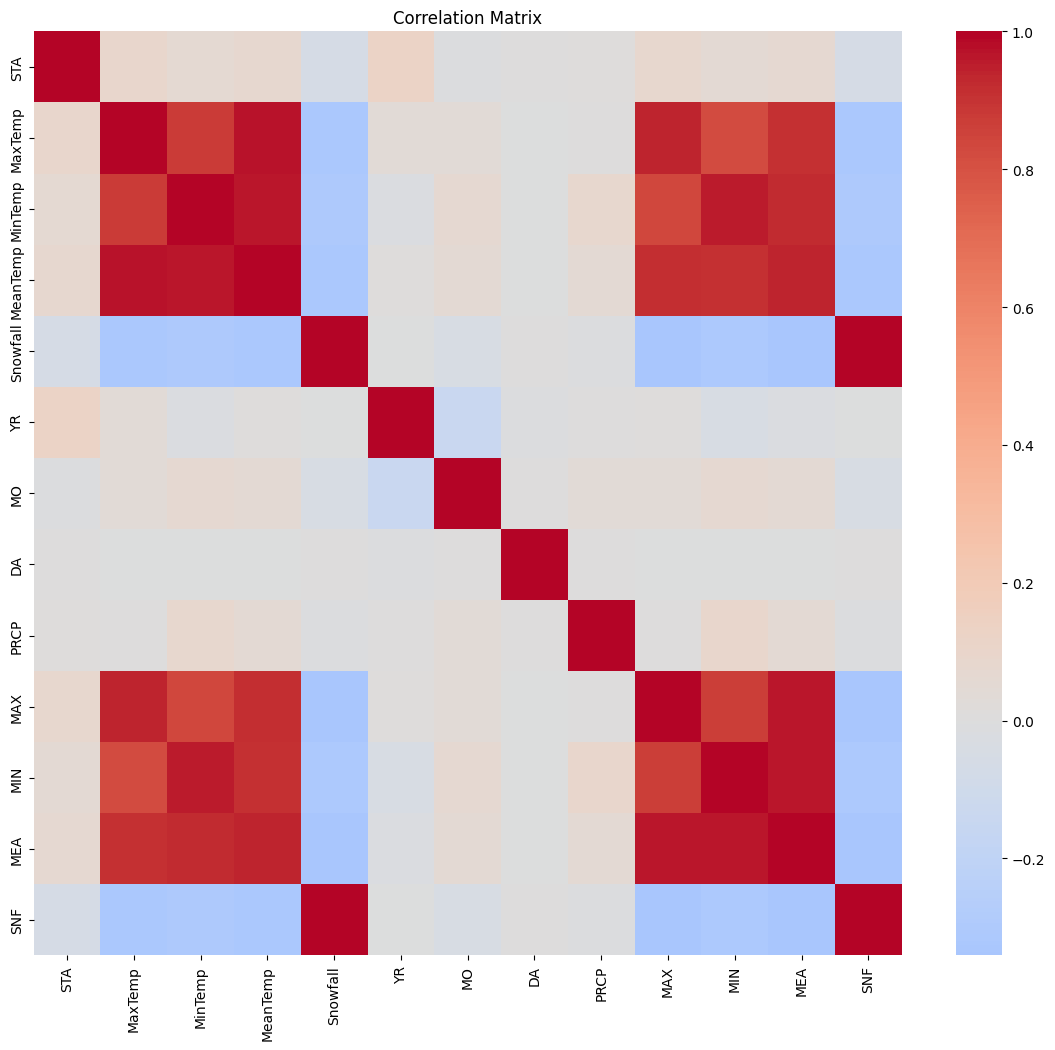

In [65]:
correlation = weather_df.corr(numeric_only=True)

plt.figure(figsize=(14,12))

sns.heatmap(
    correlation,
    cmap="coolwarm",
    center=0,
    annot=False
)

plt.title("Correlation Matrix")
plt.show()

In [66]:
correlation["MaxTemp"].sort_values(ascending=False)

,MaxTemp
MaxTemp,1.000000
MeanTemp,0.969048
MAX,0.940035
MEA,0.907613
MinTemp,0.878384
MIN,0.818503
STA,0.092371
YR,0.039585
MO,0.031346
PRCP,0.004457


### Feature Selection

Correlation analysis was used to determine which features are most relevant for predicting MaxTemp.

The selected features for predicting MaxTemp are:

*   MinTemp
*   PRCP
*   Snowfall
*   YR
*   MO

MinTemp was selected because it has a strong correlation with MaxTemp while representing a different temperature measurement, making it a useful predictor. PRCP and Snowfall describe weather conditions that may influence daily temperature. YR and MO were retained because they capture seasonal and long-term climate patterns.

The following variables were removed:

*   MeanTemp
*   MAX
*   MIN
*   MEA

These variables are highly correlated with MaxTemp and contain redundant temperature information. Removing them helps reduce multicollinearity and avoids using multiple variables that represent essentially the same measurement, resulting in a more reliable prediction model.


STA was excluded because it is a station identifier rather than a weather measurement, so it is not expected to improve temperature prediction.

## 4. Split the dataset (70% for training, 30% for testing)

In [68]:
# Select features and target variable
X = weather_df[["MinTemp", "PRCP", "Snowfall", "YR", "MO"]]

# Target variable
y = weather_df["MaxTemp"]

# Split the dataset （70% for training, 30% for testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (83328, 5)
Testing set: (35712, 5)


## 5. Choose the algorithm, train and test the model

In [69]:
# Create the model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

# Predict on the test set
y_pred = model.predict(X_test)

print("Model training completed.")

Model training completed.


## 6. Evaluate and Visualize model Performance

In [70]:
# Evaluate the model
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("R² Score:", round(r2, 4))
print("RMSE:", round(rmse, 4))

R² Score: 0.7836
RMSE: 4.0385


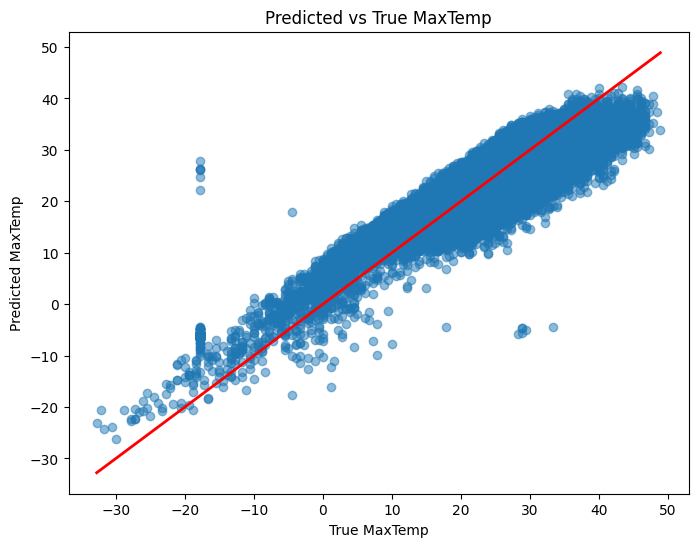

In [71]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred, alpha=0.5)

# Regression line (Ideal prediction line)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linewidth=2
)

plt.xlabel("True MaxTemp")
plt.ylabel("Predicted MaxTemp")
plt.title("Predicted vs True MaxTemp")

plt.show()

## 7. What is the R² value and RMSE of the model? How these values indicate the model performance?

###
The Linear Regression model achieved an R² score of 0.7836 and an RMSE of 4.0385.

The R² score indicates that approximately 78.36% of the variation in MaxTemp can be explained by the selected features. This suggests that the model has good predictive ability.

The RMSE means that the model's predictions differ from the actual maximum temperature by about 4 degree on average. This indicates a reasonable prediction accuracy for a simple Linear Regression model.

From the predicted versus actual values plot, most points are expected to lie close to the reference line, indicating that the model captures the general relationship between the selected weather variables and MaxTemp. However, some prediction errors remain, which suggests that other weather factors not included in the model may also influence maximum temperature.

## 8. Discuss the model performance based on the plot

The predicted versus actual MaxTemp plot shows a clear positive linear relationship between the predicted and true values. Most data points are clustered close to the red reference line, indicating that the Linear Regression model predicts the maximum temperature reasonably well. The model performs particularly well for the majority of normal temperature observations. However, some points are further away from the reference line, especially for extreme temperatures, indicating that the model has larger prediction errors in these cases. The model achieved an R² score of 0.7836, meaning that approximately 78% of the variation in MaxTemp is explained by the selected features. The RMSE of 4.04°C indicates that the average prediction error is about 4 degrees Celsius. Overall, the model demonstrates good predictive performance, although additional weather variables or a more advanced regression model may further improve prediction accuracy.